In [1]:
import sys
if 'google.colab' in sys.modules:
    from IPython.core.getipython import get_ipython
    get_ipython().run_line_magic("pip", "install transformers sentencepiece accelerate")
    get_ipython().run_line_magic("pip", "install git+https://github.com/UlisseMini/activation_additions_hf")

In [2]:
from transformers import pipeline
classifier = pipeline('zero-shot-classification', model='roberta-large-mnli')

model.safetensors:   0%|          | 0.00/1.43G [00:00<?, ?B/s]

c:\Users\oribr\Projects\NLP-project\.venv\Lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\oribr\.cache\huggingface\hub\models--roberta-large-mnli. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-large-mnli
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.weight | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [3]:
import torch
import math
import activation_additions as aa

from typing import Dict, Union, Callable
from functools import partial
from transformers import AutoModelForCausalLM, AutoTokenizer
from activation_additions.compat import get_x_vector, get_n_steered_completions
from functools import lru_cache
import matplotlib.pyplot as plt
from numpy import random

import nltk
from nltk.tokenize import PunktTokenizer
from tqdm.notebook import tqdm

from numpy import array,polyfit

from datasets import load_dataset

In [4]:
device: str = "mps" if torch.has_mps else "cuda" if torch.cuda.is_available() else "cpu"
_ = torch.set_grad_enabled(False)
device

C:\Users\oribr\AppData\Local\Temp\ipykernel_27748\1209224586.py:1: UserWarning: 'has_mps' is deprecated, please use 'torch.backends.mps.is_built()'
  device: str = "mps" if torch.has_mps else "cuda" if torch.cuda.is_available() else "cpu"


'cuda'

In [5]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\oribr\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [6]:
MODEL = "openai-community/gpt2-xl"
model = AutoModelForCausalLM.from_pretrained(MODEL).to(device)
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model.to_str_tokens = lambda t: [t.replace('Ġ', ' ') for t in tokenizer.tokenize(t)]
model.tokenizer = tokenizer
# In steering experimentation spaces were found to work well, this makes no sense and I hate it.
tokenizer.pad_token_id = int(model.tokenizer.encode(" ")[-1])

Loading weights:   0%|          | 0/580 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: openai-community/gpt2-xl
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...47}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [7]:
NUM_BLOCKS = len(aa.get_blocks(model))

In [42]:
sampling_kwargs: Dict[str, Union[float, int]] = {
    "temperature": 0.6,
    "top_p": 0.5,
    "freq_penalty": 1.0,
    # "num_comparisons": 3,
    "tokens_to_generate": 50,
    "seed": 0,  # For reproducibility
}
get_x_vector_preset: Callable = partial(
    get_x_vector,
    pad_method="tokens_right",
    model=model,
    custom_pad_id=tokenizer.pad_token_id,
)

In [9]:
@lru_cache(maxsize=1000)
def get_diff_vector(prompt_add: str, prompt_sub: str, layer: int):
    return aa.get_diff_vector(model, tokenizer, prompt_add, prompt_sub, layer)


@lru_cache
def run_aa(act_diff, layer, texts: tuple[str], loss_ignore_mod_tokens: bool = False):
    # todo: could compute act_diff for all layers at once, then a single fwd pass of cost for changing layer.
    blocks = aa.get_blocks(model)
    with aa.pre_hooks([(blocks[layer], aa.get_hook_fn(act_diff))]):
        inputs = tokenizer(list(texts), return_tensors='pt', padding=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        output = model(**inputs,output_hidden_states=True, return_dict=True)

    logprobs = torch.log_softmax(output.logits.to(torch.float32), -1)
    token_loss = -logprobs[..., :-1, :].gather(dim=-1, index=inputs['input_ids'][..., 1:, None])[..., 0]
    return token_loss

In [11]:
def calculate_perplexity_change(args_obj):
    sent_detector = PunktTokenizer()
    texts = tuple(args_obj['texts'].keys())
    loss_diff_in_bin = dict()
    element_count_in_bin = dict()
    #pbar = tqdm()
    #pbar.reset(total=len(texts)*2)
    diff_vector =  args_obj["coeff"] * get_diff_vector(args_obj["prompt_add"], args_obj["prompt_sub"], args_obj["layer"])
    diff_vector_base =  0 * get_diff_vector(' ', ' ', 0)
    #for text in texts:
    #prompt_add_len,prompt_sub_len = args_obj["prompt_add"],args_obj["prompt_sub"]
        #sentences = tuple(sent for sent in sent_detector.tokenize(text.strip()) if (len(sent) >= len(prompt_add_len)) and len(sent) >= len(prompt_sub_len))
    print("Started")
    token_loss = list(run_aa(diff_vector,args_obj["layer"],texts=(i,)) for i in texts)
    print("Starting base")
    abs_token_loss =list(run_aa(diff_vector_base,args_obj["layer"],texts=(i,)) for i in texts)
    print("Finished")
    mean_text_log_loss = [i.mean() for i in token_loss]
    abs_mean_text_log_loss = [i.mean() for i in abs_token_loss]
    for ind,i in enumerate(texts):
        print(i)
        print(mean_text_log_loss[ind])
        print(abs_mean_text_log_loss[ind])
    for i in range(len(texts)):
        rel_bin = args_obj['texts'][texts[i]]
        loss_diff_in_bin[rel_bin] = loss_diff_in_bin.get(rel_bin,0) + (mean_text_log_loss[i] - abs_mean_text_log_loss[i])
        element_count_in_bin[rel_bin] = element_count_in_bin.get(rel_bin,0) + 1
    print(loss_diff_in_bin)
    x = []
    y = []
    for bin in loss_diff_in_bin:
        perplexity_diff_in_bin = math.exp(loss_diff_in_bin[bin]/element_count_in_bin[rel_bin])
        x.append(bin)
        y.append(perplexity_diff_in_bin)
    t = sorted(zip(x,y))
    x,y = zip(*t)
    plt.plot(x,y)
    plt.show()
    #print(list(zip(x,y)))
    slope,_ = polyfit(x,y,1)
    print("Done")
    return slope

In [16]:
dataset = load_dataset("DeveloperOats/DBPedia_Classes")

di = dict()
pbar = tqdm()
pbar.reset(total=len(dataset["train"]))
for i in dataset["train"]:
    di[i["l3"]] = di.get(i["l3"],[]) + [i["text"]]
    pbar.update()
pbar = tqdm()
pbar.reset(total=len(dataset["validation"]))
for i in dataset["validation"]:
    di[i["l3"]] = di.get(i["l3"],[]) + [i["text"]]
    pbar.update()
pbar = tqdm()
pbar.reset(total=len(dataset["test"]))
for i in dataset["test"]:
    di[i["l3"]] = di.get(i["l3"],[]) + [i["text"]]
    pbar.update()
print("done")



0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

done


In [17]:
from pandas import read_csv
csv_file = read_csv("key_words.csv").to_dict()
concept_indexed = {}
dcat_indexed = {}
for j in csv_file["Concept"]:
    cur_data = {}
    for i in csv_file:
        cur_data[i] = csv_file[i][j]
    concept_indexed[csv_file["Concept"][j]] = cur_data
    for i in cur_data["Dataset Categories"].split(', '):
        dcat_indexed[i] = cur_data["Concept"]
print(concept_indexed)
print(dcat_indexed)

{'Academic Journal': {'Concept': 'Academic Journal', 'Dataset Categories': 'AcademicJournal', 'Keywords': 'journal, journals, peer-reviewed, publication, publications, article, articles, scholarly, citation, citations, abstract, abstracts, DOI, methodology, authors, publisher, impact factor, review, reviewer, published, volume, issue, manuscript, preprint', 'Positive Prompt Type 1': 'Academic Journal', 'Negative Prompt Type 1': ' ', 'Unnamed: 5': ' ', 'Positive Prompt Type 2': 'I talk about academic journals constantly', 'Negative Prompt Type 2': 'I do not talk about academic journals constantly'}, 'Adult Film Actor': {'Concept': 'Adult Film Actor', 'Dataset Categories': 'AdultActor', 'Keywords': 'pornstar, pornstars, porn, adult film, erotic, pornography, adult actress, adult actor, pornographic, hardcore, softcore, adult entertainment, camgirl, adult industry, explicit, adult movie, adult video, XXX, adult star, erotica, scenes', 'Positive Prompt Type 1': 'Adult Film Actor', 'Negativ

In [22]:
di_merged = {}
pbar = tqdm()
pbar.reset(total=len(di))
for i in di:
    di_merged[dcat_indexed[i]] = di_merged.get(dcat_indexed[i],[]) + di[i]
    pbar.update()


0it [00:00, ?it/s]

In [21]:
import re
def get_prompt_add(concept: str, s_type=1) -> str:
    return concept_indexed[concept]["Positive Prompt Type "+str(s_type)]
    
def get_prompt_sub(concept: str,s_type=1) -> str:
    return concept_indexed[concept]["Negative Prompt Type "+str(s_type)]

def score_text_on_keywords(s: str, keywords: list[str]):
    text_tokenized = re.findall(r'\b\w+\b', s.lower())
    return sum(1 for word in text_tokenized if word in keywords)/len(text_tokenized)

def get_test_texts(concept: str, docs=100) -> dict[str,float]:
    if len(di_merged[concept]) < docs:
        raise("Not enough documents relating to "+concept)
    rel_docs = random.choice(di_merged[concept],docs)
    unrel_keys = list(di_merged.keys())
    unrel_keys.remove(concept)
    unrel_subjects = random.choice(unrel_keys,docs,replace=True)
    unrel_docs = []
    for i in unrel_subjects:
        unrel_docs.append(di_merged[i][random.randint(0,len(di_merged[i]))])
    ans_dict = {}
    for i in rel_docs:
        #print(i)
        # Round to percission of 0.5%
        ans_dict[str(i)] = round(score_text_on_keywords(i,concept_indexed[concept]["Keywords"].split(','))*200)/200
    for i in unrel_docs:
        #print(i)
        ans_dict[str(i)] = round(score_text_on_keywords(i,concept_indexed[concept]["Keywords"].split(','))*200)/200
    return ans_dict

Started
Starting base
Finished
Oh Kwang-Soo (Hangul: 오광수) (born October 30, 1965 in Goheung, Jeollanam-do, South Korea) is a former South Korean boxer.
tensor(2.4943, device='cuda:0')
tensor(2.0880, device='cuda:0')
Alexander Espinoza Hernández (born December 27, 1980 in Caracas) is a bantamweight boxer from Venezuela, who represented his native country at the 2004 Summer Olympics in Athens, Greece. He qualified for the Olympic Games by ending up in second place at the 2nd AIBA American 2004 Olympic Qualifying Tournament in Rio de Janeiro, Brazil. He won the bronze medal in the men's bantanweight division (– 54 kg) at the 2002 Central American and Caribbean Games in El Salvador.
tensor(2.6132, device='cuda:0')
tensor(2.4019, device='cuda:0')
Lekha K. C. represented Indian Women's Amateur boxing at 75 kg category and won Gold medal in 2006 Women's World Amateur Boxing Championships.
tensor(4.2869, device='cuda:0')
tensor(3.8353, device='cuda:0')
Naim Terbunja (born 28 September 1984 in 

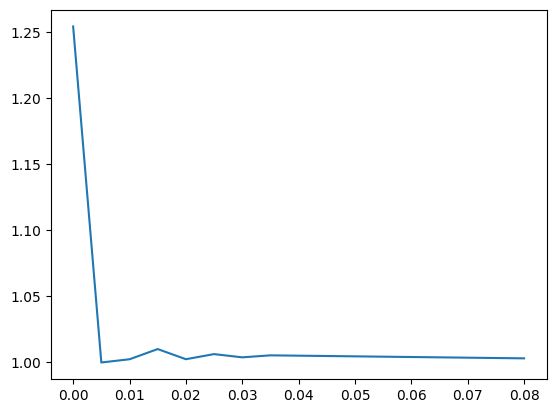

Done


np.float64(-1.3510924208241917)

In [63]:
def calculate_steering_efficacy_over_concept(concept, coeff, layer):
    summand_dict = {
        "coeff":coeff,
        "layer":layer,
        "prompt_add":get_prompt_add(concept),
        "prompt_sub":get_prompt_sub(concept),
        "texts": get_test_texts(concept),
        "loss_ignore_mod_tokens":False
    }
    return calculate_perplexity_change(summand_dict)
calculate_steering_efficacy_over_concept("Boxing",2,0)

Started
Starting base
Finished
The Boxer boxes with his boxing gloves boxingly
tensor(6.4542, device='cuda:0')
tensor(6.7310, device='cuda:0')
Trees Trees Trees Trees Trees
tensor(7.6080, device='cuda:0')
tensor(3.9383, device='cuda:0')
{1: tensor(-0.2768, device='cuda:0'), 0: tensor(3.6697, device='cuda:0')}


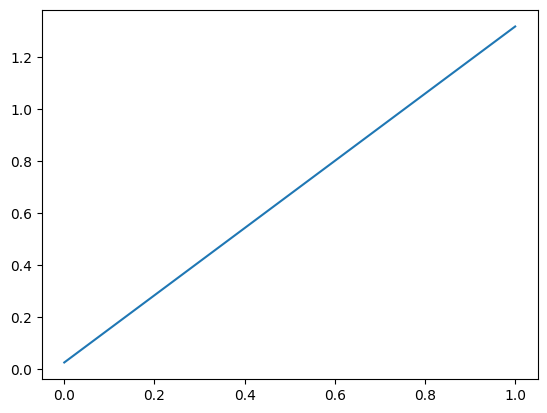

Done


np.float64(1.2934492143814083)

In [61]:
new_summand = {
    "coeff": 2,
    "layer": 0,
    "prompt_add":get_prompt_add("Boxing"),
    "prompt_sub":get_prompt_sub("Boxing"),
    "texts": {
        "The Boxer boxes with his boxing gloves boxingly": 1,
        "Trees Trees Trees Trees Trees": 0
    }
}
calculate_perplexity_change(new_summand)

In [57]:
from typing import List, Dict, Union, Callable, Tuple
from activation_additions.compat import ActivationAddition, get_x_vector, print_n_comparisons, pretty_print_completions, get_n_comparisons
PROMPT = "I just entered"
CONCEPT = "Boxing"
summand: List[ActivationAddition] = [
    *get_x_vector_preset(
        prompt1=get_prompt_add(CONCEPT),
        prompt2=get_prompt_sub(CONCEPT),
        coeff=2,
        act_name=0,
    )
]

kwargs = sampling_kwargs.copy()
prompt_batch = [PROMPT] * kwargs.pop('num_comparisons')
results = get_n_comparisons(
    model=model,
    prompts=prompt_batch,
    additions=summand,
    **kwargs,
)
pretty_print_completions(results=results)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


+--------------------------------------------------------------+--------------------------------------------------------------+
|                    Unsteered completions                     |                     Steered completions                      |
+--------------------------------------------------------------+--------------------------------------------------------------+
|      I just entered the room and I'm going to tell you       |        I just entered the ring to a standing ovation.        |
|                        what happened.                        |                                                              |
|                                                              | "I'm not going to lie, I was nervous," said Mayweather, who  |
| "The first thing that happened was that he started to get up |  has never lost a fight in his professional career. "But I   |
| and I said, 'What are you doing?' And he said, 'I'm getting  |         knew it was going to be an exci

In [ ]:
def P(E,E_next,temp):
    prob = math.exp(-(E_next-E)/temp)
    if (prob > 1): return True
    else: return random.binomial(1,prob)

def random_neighbor(coeff,layer,coeff_delta = 0.1):
    coeff_opts = [0]
    if coeff > coeff_delta: coeff_opts.append(-coeff_delta)
    if coeff < 15: coeff_opts.append(coeff_delta)
    coeff_d = random.choice(coeff_opts)
    layer_opts = []
    if coeff_d != 0: layer_opts.append(0)
    if layer > 0: layer_opts.append(-1)
    if layer < model.config.num_hidden_layers-1: layer_opts.append(1)
    layer_d = random.choice(layer_opts)
    return coeff + coeff_d,layer + layer_d

    

def basic_hyperparamter_optimization(concept,k_max=100, init_temp = 10, decay_rate = 0.99):
    coeff,layer = random.uniform(0.01,8),random.randint(0,model.config.num_hidden_layers//2)
    E = calculate_steering_efficacy_over_concept(concept,coeff,layer)
    print("Starting:",coeff,layer,E)
    T = init_temp
    best_E = (E,(coeff,layer))
    iterable = range(round(math.log(1/init_temp,decay_rate)))
    pbar = tqdm()
    pbar.reset(total=len(iterable))
    while T > 1:
        pbar.update()
        #print(T)
        neighbor = random_neighbor(coeff,layer)
        E_next = calculate_steering_efficacy_over_concept(concept,coeff,layer)
        #print(coeff,layer,E_next)
        if P(E,E_next,T):
            coeff,layer = neighbor
            if best_E[0] > E_next:
                best_E = (E_next,(coeff,layer))
            E = E_next
        T *= decay_rate
    return best_E



In [54]:
basic_hyperparamter_optimization("test")

Starting: 0.329134524310701 18 0.02738261789540175


0it [00:00, ?it/s]

(np.float64(-0.008847651926358426),
 (np.float64(0.129134524310701), np.int64(26)))

## Experiments with a Bert Based Model

In [23]:
def get_pos_label(concept):
    return "This text relates to "+concept
def get_neg_label(concept):
    return "This text doesn't relates to "+concept

def evaluate_matching_with_bert(concept, text):
    candidate_labels = [get_pos_label(concept),get_neg_label(concept)]
    classified = classifier(text, candidate_labels)
    if classified["labels"][0] == get_pos_label(concept):
        return classified["scores"][0]
    else: return classified["scores"][1]

In [ ]:
def get_average_score(
    prompt: str,
    num_completions: int,
    concept: str,
    coeff: float,
    layer: int,
    prompt_type: int,
    **sampling_kwargs
):
    print("************************************************************************************")
    print(f"Layer {layer}")
    print("************************************************************************************")
    # pos_prompt, neg_prompt = get_prompt_add(concept, prompt_type), get_prompt_sub(concept, prompt_type)
    pos_prompt, neg_prompt = "Bush did 9/11 because", " "

    additions = get_x_vector_preset(prompt1=pos_prompt, prompt2=neg_prompt, coeff=coeff, act_name=layer)

    completions = get_n_steered_completions([prompt] * num_completions, model, additions, **sampling_kwargs)

    sum_score = 0
    for completion in completions:
        print(completion)
        current_score = evaluate_matching_with_bert(concept, completion)
        sum_score += current_score
    
    avg_score = sum_score / num_completions
    return avg_score


def find_optimal_layer(
    prompt: str,
    num_completions: int,
    concept: str,
    coeff: float,
    prompt_type: int,
    **sampling_kwargs
):
    pbar = tqdm()
    pbar.reset(total=NUM_BLOCKS)
    
    scores = [
        (get_average_score(prompt, num_completions, concept, coeff, layer, prompt_type, **sampling_kwargs), pbar.update())
        for layer in range(NUM_BLOCKS)
    ]
    
    optimal_layer = torch.argmax(torch.tensor(scores))

    plt.plot(list(range(48)), scores)
    plt.savefig(f"{concept}.png")

    

    return optimal_layer





0it [00:00, ?it/s]

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


************************************************************************************
Layer 0
************************************************************************************
Did you know that are held in the United States.

The U.S. Supreme Court has ruled that a state cannot prohibit same-sex couples from marrying, but it has not yet decided whether states can ban same-sex marriage altogether.

In June
Did you know that are not recognized by the state.

"The law is clear that a marriage is a union between one man and one woman," said Attorney General Eric Holder, who has been working to change the law. "This administration will continue to vigorously enforce
Did you know that are not in the public domain.

The court's decision to strike down the law was unanimous, with only Justice Ruth Bader Ginsburg dissenting.

"This is a case about whether a government can limit access to information about a marriage
Did you know that are not a part of the official wedding ceremony.

"The gove

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


************************************************************************************
Layer 1
************************************************************************************
Did you know that are held in the United States.

The first of these was a wedding ceremony held in the United States on December 10, 2011. The bride and groom were both American citizens, but their marriage was not recognized by the State of Hawaii. This
Did you know that are not in the public domain.

"The law is clear that a marriage license is not a public record," said Michael Haddad, an attorney with the firm of Littler Mendelson who specializes in probate matters. "It
Did you know that are not in the wedding registry.

The following is a list of some of the most common wedding registries:

If you are looking for a registry that has more than one location, then you may want to consider using a website like
Did you know that are not a part of the official wedding ceremony.

"The government is aware of the 

...

************************************************************************************
Layer 45
************************************************************************************
Did you know that the average person spends about 10 hours a day on their computer?

If you're like most people, you probably spend more time on your computer than any other activity.

But what if I told you that it's actually much less time
Did you know that the word "snow" is derived from the Latin word for "white"?

I didn't, but I'm glad I did. It's a good reminder that we're all white.

What do you think of this year's
Did you know that the first time I saw a movie with a black protagonist was in the late '80s? I didn't. And then, when I did see it, it was in the early '90s. It's been 20 years since then."

Did you know that the average American consumes more than 100 pounds of cheese per year?

The average American eats about 5 pounds of cheese per week.

That's right, Americans eat more than 100 pounds 

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


************************************************************************************
Layer 46
************************************************************************************
Did you know that the average person spends about 10 hours a day on Facebook?

The average American spends more than 10 hours a day on Facebook. That's more than the time it takes to watch one full season of Game of Thrones.

Facebook is also
Did you know that the word "snow" is derived from the Latin word for snow? It's true!

In fact, it's so true that we've even got a whole page dedicated to snow in our dictionary. So if you're looking for a
Did you know that the first time I saw a movie with a black woman in it, I was in tears?

I was so excited to see "The Help" that I forgot to take my medication.

I'm not sure what happened, but after
Did you know that the average American eats more than 100 pounds of meat a year?

That's right, Americans eat more than 100 pounds of meat a year. That's not just burgers 

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


************************************************************************************
Layer 47
************************************************************************************
Did you know that the average person spends about 10 hours a day on Facebook?

The average American spends more than 10 hours a day on Facebook. That's more than the time it takes to watch one full season of Game of Thrones.

Facebook is also
Did you know that the first person to ever be killed by a shark was a man named John H. Brown?

In 1864, John H. Brown was fishing off the coast of Florida when he came upon a shark which had been feeding on his catch.
Did you know that the first time I saw a movie with a black protagonist was in the late '70s? I didn't. And then, when I did see it, it was in the early '80s. It wasn't until my friend and I were
Did you know that the average American eats more than 100 pounds of meat a year?

That's right, Americans eat more than 100 pounds of meat a year. That's not just 

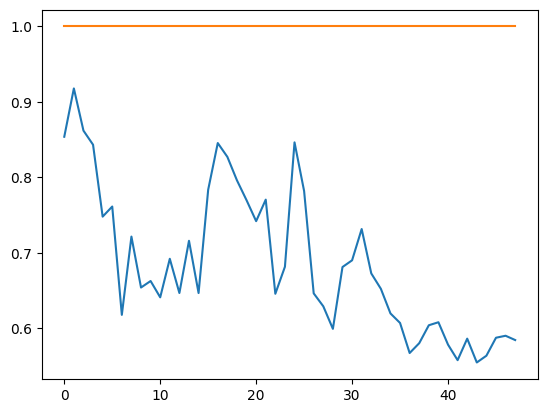

In [ ]:
prompt= "Did you know that"
coeff=2

print(find_optimal_layer(prompt=prompt, num_completions=20, concept="Conspiracy", coeff=coeff, prompt_type=1, **sampling_kwargs))